# Pausa práctica 2 — Fundamentos en código

**Contexto:** acabamos de ver qubit, superposición, entrelazamiento y decoherencia en la pizarra. Ahora lo mismo, pero corriendo en un simulador cuántico real con Qiskit.

Dos demos:
1. **Superposición** — la compuerta Hadamard, medida 1000 veces
2. **Entrelazamiento** — el estado de Bell |Φ+⟩ que vimos en la ecuación

In [5]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00


In [6]:
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

sim = AerSimulator()


## Demo 1 — Superposición (compuerta Hadamard)

In [7]:
qc_h = QuantumCircuit(1, 1)
qc_h.h(0)          # Hadamard: pone el qubit en superposición |0> + |1>
qc_h.measure(0, 0)

print(qc_h.draw())


     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


Resultados de 1000 mediciones: {'0': 489, '1': 511}


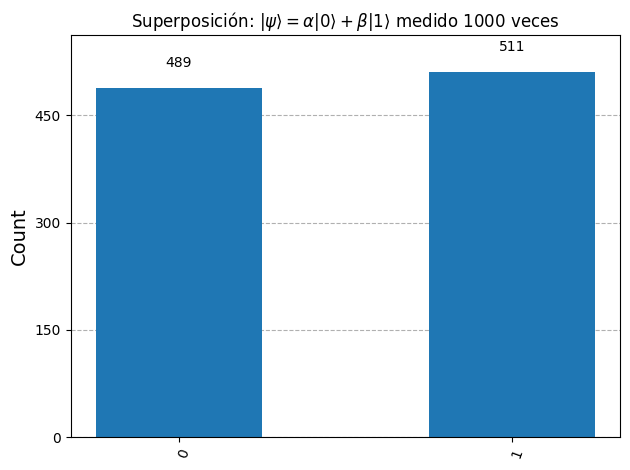

In [12]:
job = sim.run(qc_h, shots=1000)
counts = job.result().get_counts()
print("Resultados de 1000 mediciones:", counts)

fig = plot_histogram(counts, title=r"Superposición: $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ medido 1000 veces")
fig.savefig("superposicion.png", dpi=140, bbox_inches="tight")
display(fig)

**Para la charla:** con α = β = 1/√2, esperamos ~50% de 0 y ~50% de 1. La distribución nunca es exactamente 50/50 — eso también es parte de la lección: estamos midiendo *probabilidades*, no certezas.

## Demo 2 — Entrelazamiento (estado de Bell)

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

In [9]:
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)        # superposición en el primer qubit
qc_bell.cx(0, 1)    # CNOT: entrelaza el qubit 0 con el qubit 1
qc_bell.measure([0, 1], [0, 1])

print(qc_bell.draw())


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


Resultados de 1000 mediciones: {'11': 499, '00': 501}


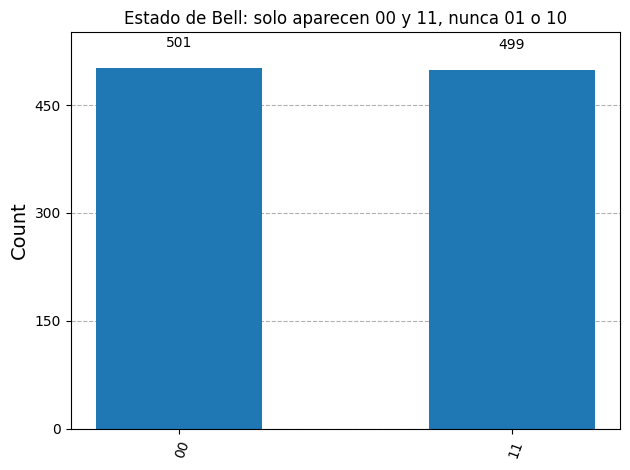

In [11]:
job_bell = sim.run(qc_bell, shots=1000)
counts_bell = job_bell.result().get_counts()
print("Resultados de 1000 mediciones:", counts_bell)

fig = plot_histogram(counts_bell, title="Estado de Bell: solo aparecen 00 y 11, nunca 01 o 10")
fig.savefig("entrelazamiento.png", dpi=140, bbox_inches="tight")
display(fig)


En el histograma solo aparecen las barras `00` y `11` — nunca `01` ni `10`. Eso es exactamente lo que dijimos en la diapositiva: medir un qubit determina instantáneamente el resultado del otro. Es matemáticamente imposible que salgan distintos.